In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [4]:
# 1. Carga de datos
df = pd.read_csv('wine_data.csv')

In [6]:
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline,Clase
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065,1
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050,1
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185,1
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480,1
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735,1


In [5]:
# 2. Limpieza y Preprocesamiento
print("--- Info del Dataset ---")
print(df.info())
print("\nValores nulos:", df.isnull().sum().sum())

--- Info del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
 13  Clase                 178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
No

In [9]:
df['Clase'].unique() #clasificación multiclase

array([1, 2, 3])

In [10]:
# Separar características (X) y objetivo (y)
X = df.drop('Clase', axis=1)
y = df['Clase']

In [11]:
# Escalamiento de datos (importante para visualización y algunos modelos)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

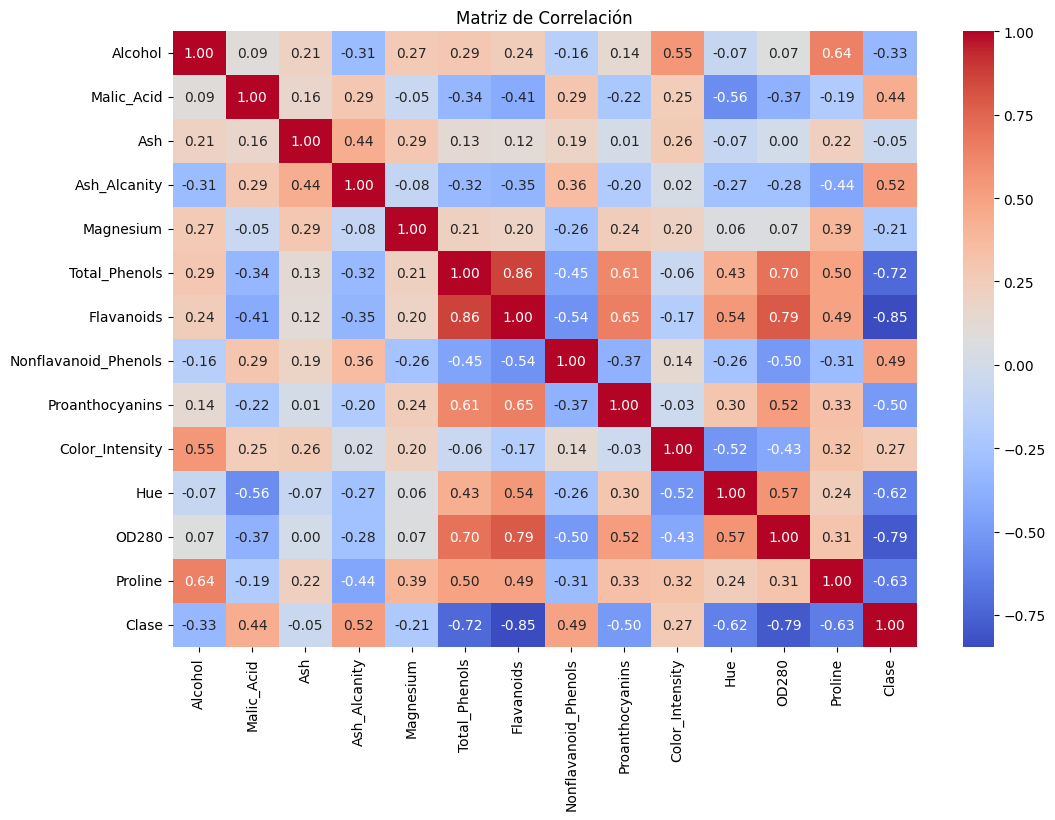

In [13]:
# 3. Verificación de Correlaciones
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matriz de Correlación")
plt.show()

In [14]:
# 4. Construcción de Modelos (Bagging vs Boosting)

# A. Bagging: Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [15]:
# B. Boosting: Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
gb_pred = gb_model.predict(X_test)

In [17]:
rf_pred_train = rf_model.predict(X_train)
gb_pred_train = gb_model.predict(X_train)
print(f"Accuracy Random Forest: {accuracy_score(y_train, rf_pred_train):.4f}")
print(f"Accuracy Gradient Boosting: {accuracy_score(y_train, gb_pred_train):.4f}")

Accuracy Random Forest: 1.0000
Accuracy Gradient Boosting: 1.0000


In [16]:
print(f"Accuracy Random Forest: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Accuracy Gradient Boosting: {accuracy_score(y_test, gb_pred):.4f}")

Accuracy Random Forest: 1.0000
Accuracy Gradient Boosting: 0.9444


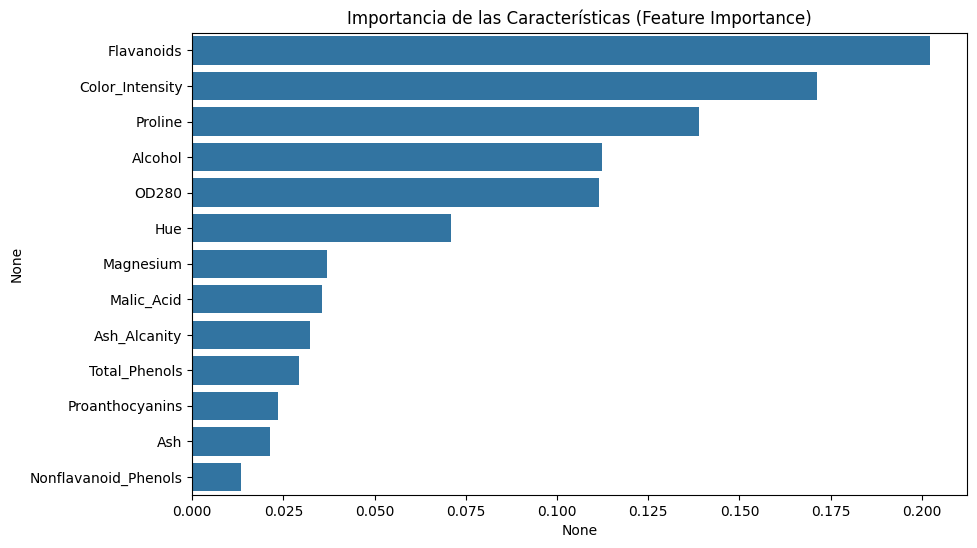

In [18]:
# 5. Feature Importance (usando Random Forest)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index)
plt.title("Importancia de las Características (Feature Importance)")
plt.show()

In [19]:
# 6. Hiperparametrización (Tuning del mejor modelo: Gradient Boosting)
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'subsample': [0.8, 1.0]
}

grid_search = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)




GridSearchCV(cv=5, estimator=GradientBoostingClassifier(random_state=42),
             param_grid={'learning_rate': [0.01, 0.1, 0.2],
                         'max_depth': [3, 4, 5], 'n_estimators': [50, 100, 150],
                         'subsample': [0.8, 1.0]},
             scoring='accuracy')


Mejores Hiperparámetros: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 150, 'subsample': 0.8}

--- Reporte de Clasificación Final ---
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        14
           3       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



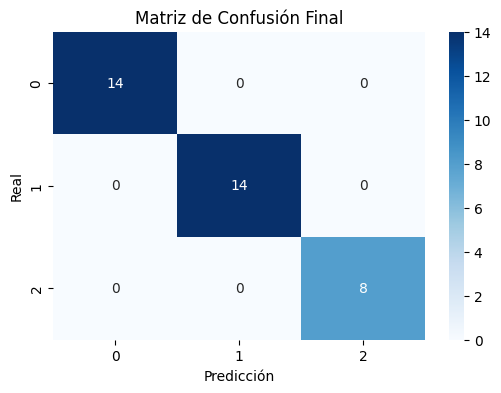

In [20]:
best_model = grid_search.best_params_
print(f"\nMejores Hiperparámetros: {best_model}")

# Evaluación Final
final_pred = grid_search.predict(X_test)
print("\n--- Reporte de Clasificación Final ---")
print(classification_report(y_test, final_pred))

# Matriz de Confusión Final
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, final_pred), annot=True, cmap='Blues', fmt='g')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión Final')
plt.show()

In [21]:
# B. Boosting: Gradient Boosting
gb_model_best = GradientBoostingClassifier(random_state=42,learning_rate=0.1, max_depth= 4, n_estimators=150, subsample=0.8)
gb_model_best.fit(X_train, y_train)
gb_pred_best = gb_model_best.predict(X_test)

In [22]:
print(f"Accuracy Gradient Boosting: {accuracy_score(y_test, gb_pred_best):.4f}")

Accuracy Gradient Boosting: 1.0000
